### Q2

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

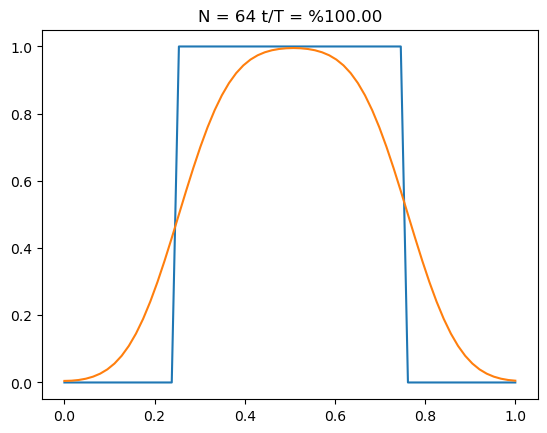

In [12]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_= np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[-1] = a[0]
    a_[0]  = a[-1]
    return a_
    
def upwind(a,C):
    a = goust_func(a)
    ai = a[1:-1]; aii = a[0:-2]
    return ai - C*(ai-aii)

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)

def upwind_advection(C=0.5, N=64, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/u; dt = C/u * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    for tt in range(len(t_vec)):
        
        step_ = upwind(step[-1],C)
        step.append(step_)
        
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step


    print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")
if upwind_advection:
    upwind_advection()
        

    

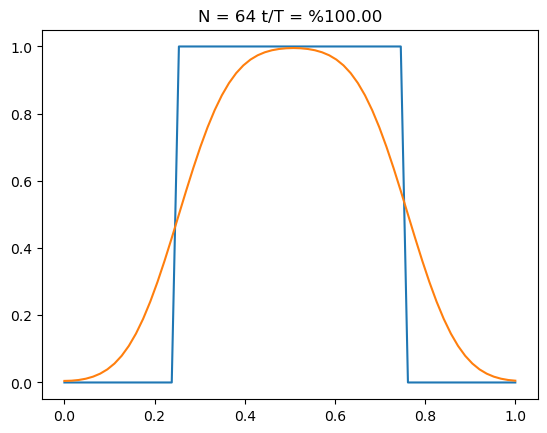

eps = 4.18480e-02


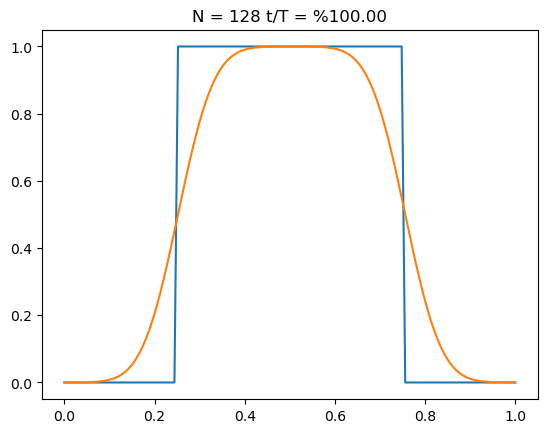

eps = 2.94005e-02


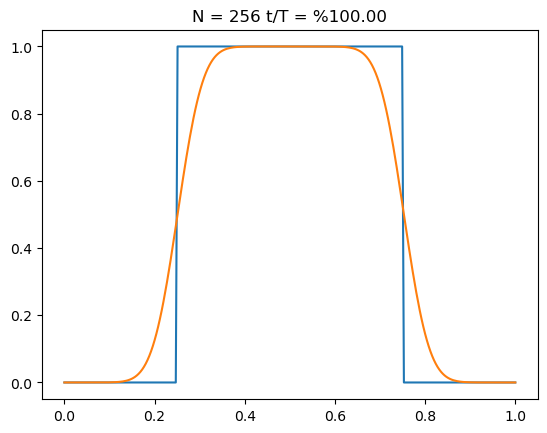

eps = 2.07226e-02


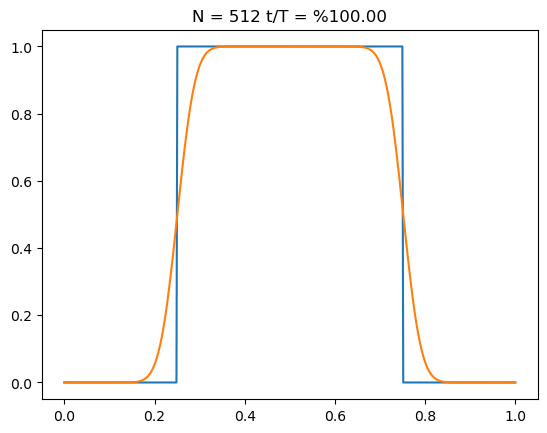

eps = 1.46295e-02


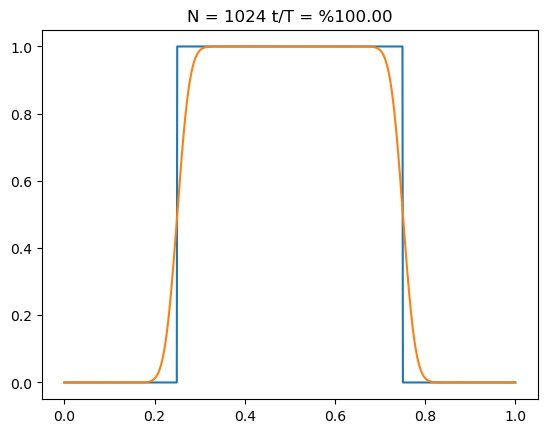

eps = 1.03363e-02


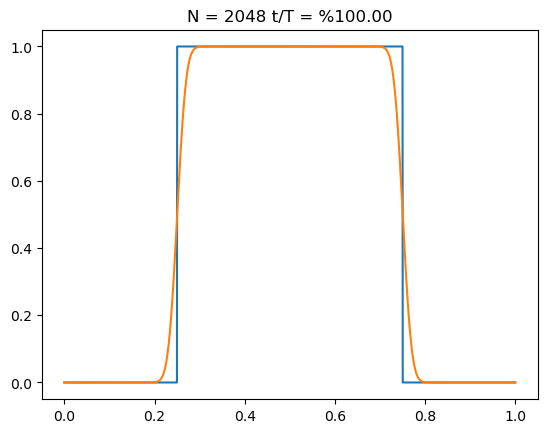

eps = 7.30592e-03


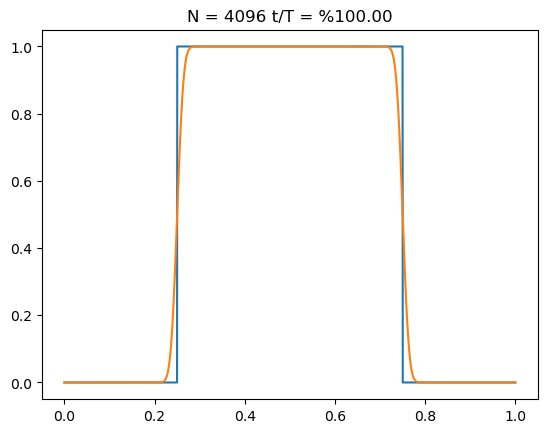

eps = 5.16502e-03


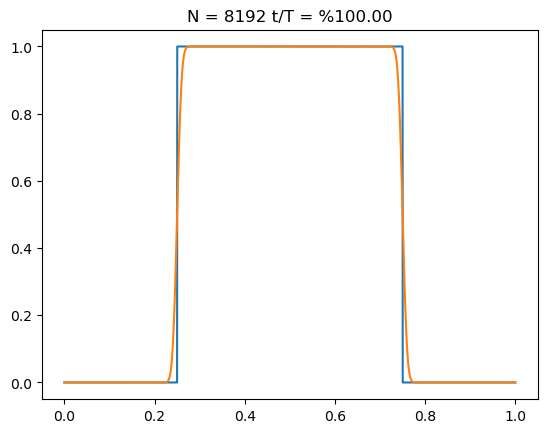

eps = 3.65185e-03


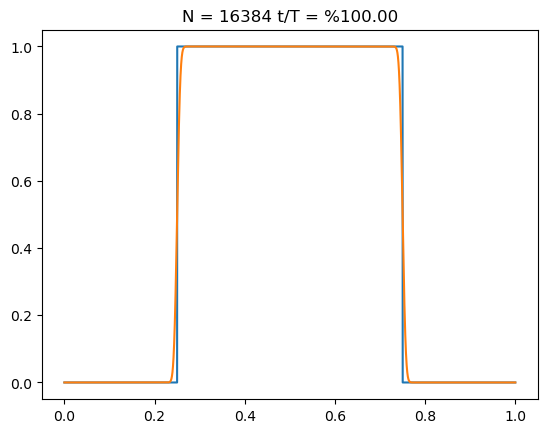

eps = 2.58212e-03


In [14]:
power_vec = np.arange(6,15,1);
N_vec = 2**power_vec
eps = []
for N in N_vec:
    a = upwind_advection(C=0.5 ,N=N , u=1, plot_init=True, plot_mid=False, plot_end=True)
    eps.append(eps_func(a[-1],a[0],N))
    print(f'eps = {eps[-1]:.5e}')
    



In [59]:
for n in range(len(N_vec)):
    N = N_vec[n]
    e = eps[n]
    print (f"The error for N = {N} is eps={e:.2e}")


The error for N = 64 is eps=4.62e-02
The error for N = 128 is eps=3.10e-02
The error for N = 256 is eps=2.13e-02
The error for N = 512 is eps=1.48e-02
The error for N = 1024 is eps=1.04e-02
The error for N = 2048 is eps=7.33e-03
The error for N = 4096 is eps=5.17e-03
The error for N = 8192 is eps=3.65e-03
The error for N = 16384 is eps=2.58e-03


##### b

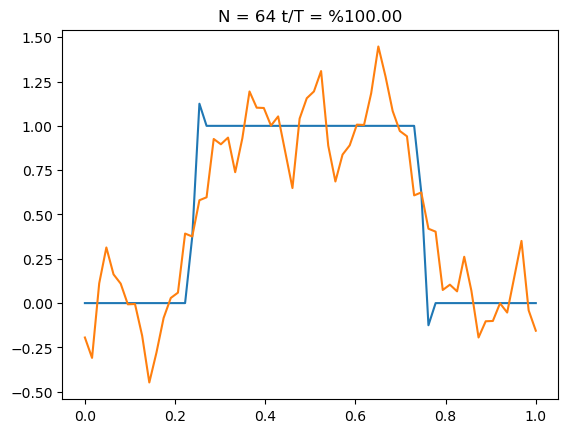

In [19]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):

    
    a_ = np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[-1] = a[0]; #  a_N-1 = a_0
    # a_[-1] = a[1] # a_N = a1
    a_[0] = a[-1]  # a_-1 = a_N-2
    return a_
    
def lax_func (a,C):
    a_ = goust_func(a)
    aip1 = a_[2:]; aim1 = a_[:-2]
    return a + C/2*(aip1-aim1)+ (C**2)/2 * (aip1+aim1-2*a)
    
    
def upwind(a,a_prev_n,C):
    a_ = goust_func(a)    
    aip1 = a_[2:]; aim1 = a_[:-2]
    return a_prev_n - C*(aip1-aim1)

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)




def leapfrog_func(C=0.5, N=2**6, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/u; dt = C/u * dx
    step = []
    stepm2 = np.zeros(N)
    # print(stepm2[0])
    # step.append(stepm2)
    step.append(step_func(N))
    step.append(lax_func (step[-1],C))
    # step.append(step_func(N))
    # print(step[-1])
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(len(t_vec)):
        
        step_new = upwind(step[-1],step[-2],C)
        # print(len(step_tx))
        step.append(step_new)
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step
        
if leapfrog_func:
    leapfrog_func()


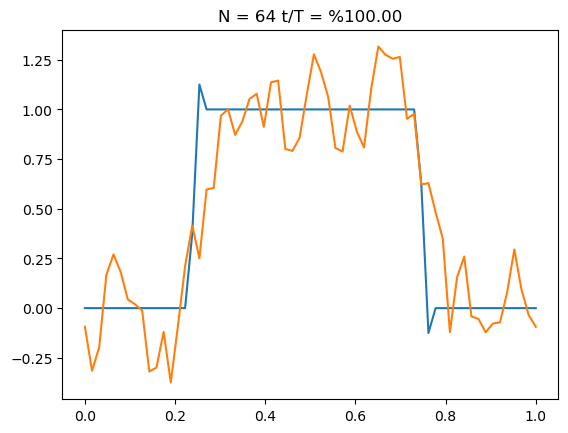

eps = 5.68100e-02


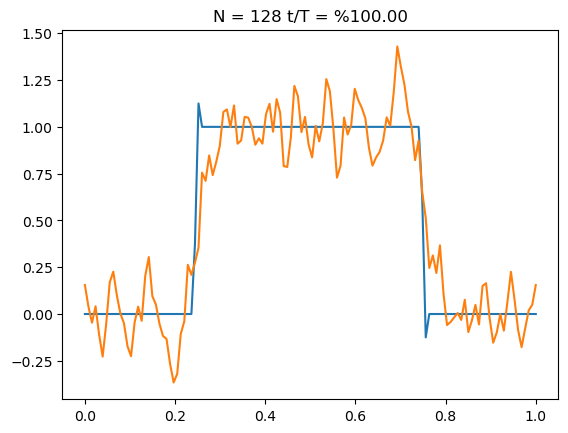

eps = 2.96747e-02


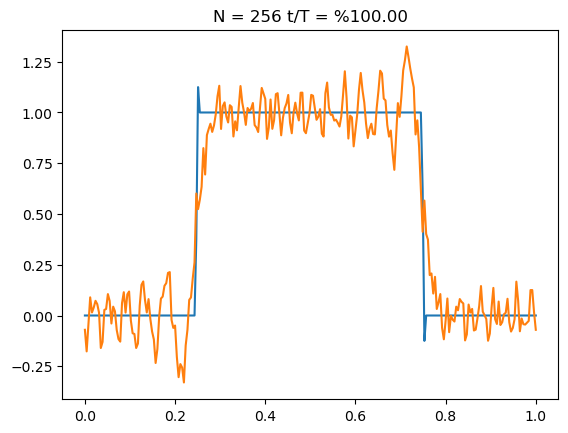

eps = 1.93291e-02


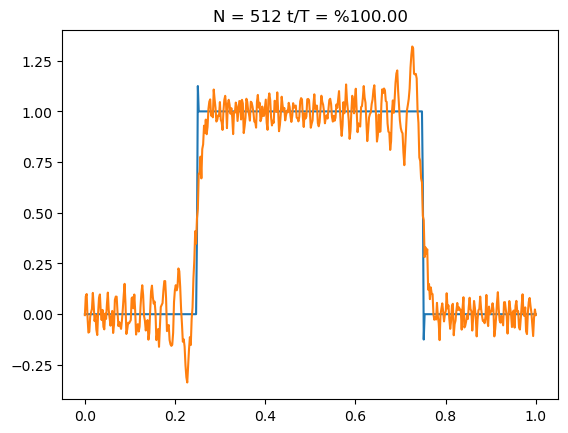

eps = 1.11219e-02


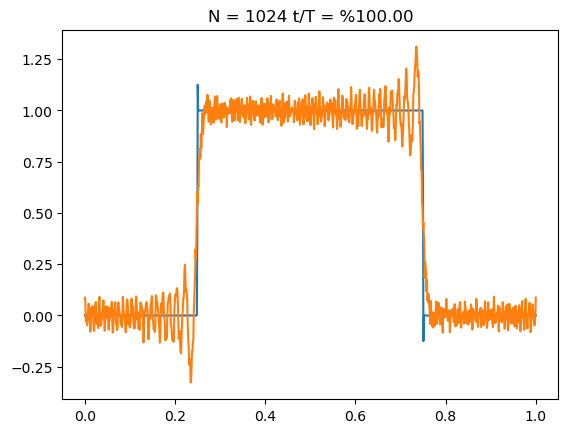

eps = 7.34973e-03


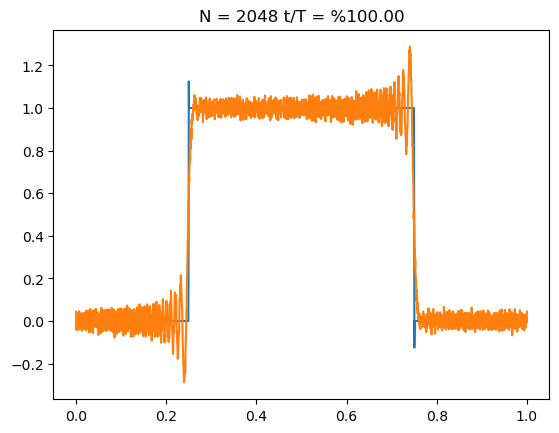

eps = 4.48824e-03


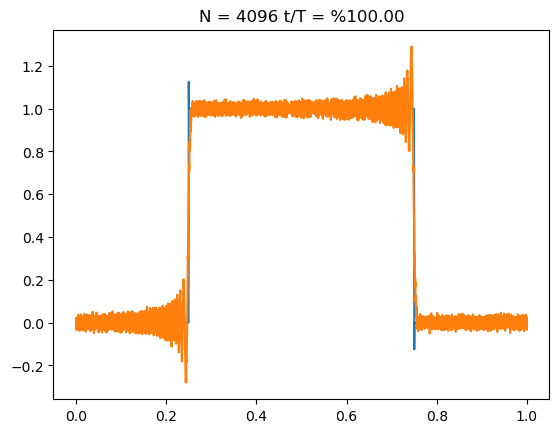

eps = 2.83599e-03


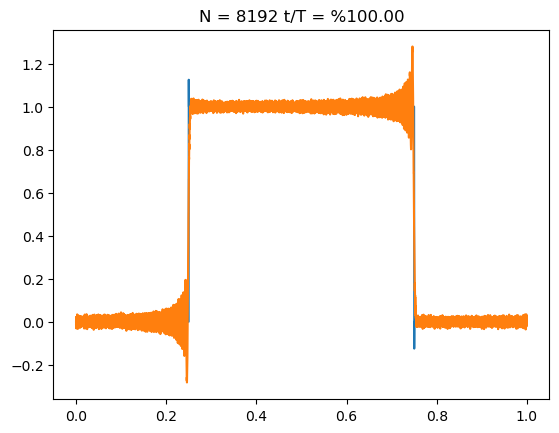

eps = 1.79319e-03


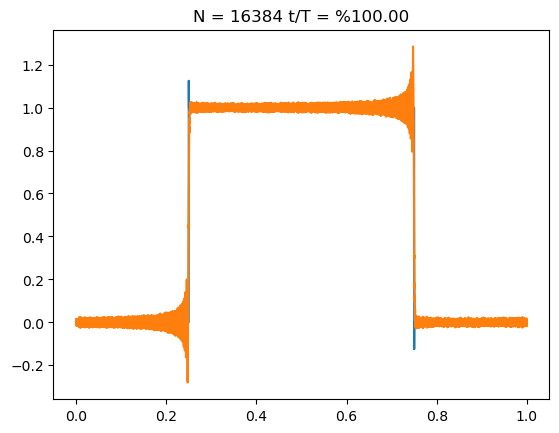

eps = 1.13332e-03


In [61]:
power_vec = np.arange(6,15,1);
N_vec = 2**power_vec
eps = []
for N in N_vec:
    a = leapfrog_func(C=0.5 ,N=N , u=1, plot_init=True, plot_mid=False, plot_end=True)
    eps.append(eps_func(a[-1],a[0],N))
    print(f'eps = {eps[-1]:.5e}')
    

In [62]:
for n in range(len(N_vec)):
    N = N_vec[n]
    e = eps[n]
    print (f"The error of leapfrog for N = {N} is eps={e:.2e}")


The error of leapfrog for N = 64 is eps=5.68e-02
The error of leapfrog for N = 128 is eps=2.97e-02
The error of leapfrog for N = 256 is eps=1.93e-02
The error of leapfrog for N = 512 is eps=1.11e-02
The error of leapfrog for N = 1024 is eps=7.35e-03
The error of leapfrog for N = 2048 is eps=4.49e-03
The error of leapfrog for N = 4096 is eps=2.84e-03
The error of leapfrog for N = 8192 is eps=1.79e-03
The error of leapfrog for N = 16384 is eps=1.13e-03
